In [68]:
import os
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from scipy.ndimage import distance_transform_edt, label
import torch
from monai.transforms import (
    MapTransform,
    Compose,
    LoadImaged,
    EnsureChannelFirstd, 
    Lambdad, 
    EnsureTyped)

import numpy as np
import pandas as pd
import seaborn as sns

In [69]:
class ComputeWeightMapsd(MapTransform):
    def __init__(self, keys, concept, allow_missing_keys=False, mountain_sigma_sc=1, island_sigma_sc=5):
        super().__init__(keys, allow_missing_keys)
        self.mountain_sigma = mountain_sigma_sc
        self.island_sigma = island_sigma_sc
        allowed_maps = ['none', 'iw', 'v_region', 'v_iw',
                        'v_mountains', 'v_islands', 'v_adaptive']
        assert concept in allowed_maps, f'Provided weight map {concept} not valid. Choose one of {allowed_maps}'
        self.concept = concept

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            instances = d.get(f"instances")
            voronoi = d.get(f"voronoi")

            if instances is None or voronoi is None:
                raise KeyError(f"Voronoi or Instance maps not found for key: {key}. "
                               "Ensure ComputeVoronoiMapsd is run first.")

            inst_np = instances.detach().cpu().numpy(
            ) if torch.is_tensor(instances) else instances
            vor_np = voronoi.detach().cpu().numpy() if torch.is_tensor(voronoi) else voronoi
            
            # Remove first dimension
            inst_np = inst_np[0]
            vor_np = vor_np[0] 
            assert vor_np.ndim == 2 or vor_np.ndim == 3, f"Weight map computaion of mask dimension {vor_np.ndim} and shape {vor_np.shape} is not supported"

            # Instantiate map as unit tensor
            map = np.ones_like(inst_np, dtype=np.float32)
            map2 = np.ones_like(inst_np, dtype=np.float32)

            # The overall budget that can be distributed (B)
            total_budget = inst_np.size

            region_ids = np.unique(vor_np)
            region_ids = region_ids[region_ids != 0]

            distance_map = distance_transform_edt(inst_np == 0)

            for idx in region_ids:
                inst_mask = (inst_np == idx)
                vor_mask = (vor_np == idx)
                bg_mask = vor_mask & ~inst_mask

                area_inst = np.sum(inst_mask)
                area_vor = np.sum(vor_mask)
                area_bg = np.sum(bg_mask)

                region_budget = total_budget/len(region_ids)
                if self.concept == 'iw':
                    map[inst_mask] = total_budget / \
                        ((len(region_ids)+1)*area_inst)
                    map[bg_mask] = total_budget / \
                        ((len(region_ids)+1)*np.sum(inst_np == 0))
                elif self.concept == 'v_region':
                    map[vor_mask] = region_budget / area_vor
                elif self.concept == 'v_iw':
                    alpha = 0.5
                    map[inst_mask] = alpha * \
                        region_budget / area_inst
                    map[bg_mask] = (
                        1-alpha) * region_budget / area_bg
                elif self.concept == 'v_adaptive':
                    alpha = 0.5
                    map[vor_mask] = region_budget / area_vor
                    map2[inst_mask] = alpha * \
                        region_budget / area_inst
                    map2[bg_mask] = (
                        1-alpha) * region_budget / area_bg
                elif self.concept == 'v_mountains':
                    sigma = self.mountain_sigma * np.sqrt(area_inst / np.pi)
                    # Lower bound to prevent division by zero
                    sigma = max(sigma, 1.0)
                    dists = distance_map[bg_mask]
                    bg_decay = np.exp(-dists / sigma)
                    bg_integral = np.sum(bg_decay)

                    w_l = region_budget / (area_inst + bg_integral)
                    map[inst_mask] = w_l
                    map[bg_mask] = w_l * bg_decay
                elif self.concept == 'v_islands':
                    sigma = self.island_sigma * np.sqrt(area_inst / np.pi)
                    # Lower bound to prevent division by zero
                    sigma = max(sigma, 1.0)
                    dists = distance_map[bg_mask]
                    island_growth = 1.0 - np.exp(-dists / sigma)
                    i_integral = np.sum(island_growth)

                    w_l = region_budget / (area_inst + i_integral)

                    map[inst_mask] = w_l
                    map[bg_mask] = w_l * island_growth

            map_sum = np.sum(map)
            unit_sum = np.sum(np.ones_like(map))
            total_delta = np.abs(map_sum - unit_sum)
            assert total_delta < (
                1e-5 * unit_sum), f"Sum over weight map {self.concept} not within range of unit tensor, difference: {total_delta}"
            map = torch.from_numpy(map[None, ...])
            map2 = torch.from_numpy(map2[None, ...])
            if torch.is_tensor(instances):
                map = map.to(instances.device)
                map2 = map2.to(instances.device)
            d['weight_map'] = map
            d['v_iw'] = map2
        return d

def voronoi_map_from_binary_mask(mask: np.ndarray, min_size=14):
    """
    mask: (H, W, optional D) binary ground truth
    Returns:
        voronoi_map: (H, W, optional D) int, Voronoi region id
        cc_labels:   (H, W, optional D) int, connected components
    """
    if mask.ndim == 2:
        # 8-connectivity for 2d images
        connector = np.ones((3, 3), dtype=np.int32)
    elif mask.ndim == 3:
        # 26-connectivity for 3d images
        connector = np.ones((3, 3, 3), dtype=np.int32)
    else:
        raise IndexError(
            f"Voronoi computaion of mask dimension {mask.ndim} and shape {mask.shape} is not supported")
    cc_labels, num_cc = label(mask > 0, connector)

    if num_cc == 0:
        return np.zeros_like(cc_labels), cc_labels

    # distance_transform_edt assigns each pixel to nearest foreground voxel
    _, indices = distance_transform_edt(
        cc_labels == 0, return_indices=True
    )

    voronoi_map = cc_labels[tuple(indices)]
    assert mask.shape == voronoi_map.shape, f"Mask shape {mask.shape} and voronoi map shape {voronoi_map.shape} not equal"
    assert mask.shape == cc_labels.shape, f"Mask shape {mask.shape} and labelmap shape {cc_labels.shape} not equal"
    return voronoi_map, cc_labels


class ComputeVoronoiMapsd(MapTransform):
    """
    Computes CC labels and Voronoi regions as a Monai transform for 2d or 3d labels.
    """

    def __call__(self, data):
        d = dict(data)

        for key in self.keys:
            mask = d[key]
            if isinstance(mask, torch.Tensor):
                mask = mask.detach().cpu().numpy()

            # Expect (1, H, W, optional D)
            mask = mask[0]
            voronoi, cc = voronoi_map_from_binary_mask(mask)

            d["voronoi"] = torch.from_numpy(voronoi).long()
            d["instances"] = torch.from_numpy(cc).long()
        return d

In [70]:
transforms = Compose([
    LoadImaged(keys=['label']),
    EnsureChannelFirstd(keys=["label"]),
    Lambdad(keys=["label"], func=lambda x: (
        x == 255).astype(x.dtype)),
    ComputeVoronoiMapsd(keys=["label"]),
    EnsureChannelFirstd(
        keys=["voronoi", "instances"], channel_dim="no_channel"),
    ComputeWeightMapsd(
        keys=["label"], concept='iw', mountain_sigma_sc=2, island_sigma_sc=5),
    EnsureTyped(keys=["label", "voronoi", "weight_map", 'v_iw', "instances"]),])

superset = 'epfl_clean'
task = 'mit'

samples = transforms([{'label': f'../data/datasets/{superset}/val/labels/{task}/{file}'}
           for file in os.listdir(f'../data/datasets/{superset}/val/labels/{task}')] + [{'label': f'../data/datasets/{superset}/train/labels/{task}/{file}'}
                                                                                                                               for file in os.listdir(f'../data/datasets/{superset}/train/labels/{task}')])
len(samples)

247

In [71]:
def extract_morphological_metrics(samples):
    records = []

    for img_idx, sample in enumerate(samples):
        # Extract tensors, drop the channel dimension ([1, H, W] -> [H, W]), and convert to numpy
        instances = sample['instances'].squeeze()
        voronoi = sample['voronoi'].squeeze()

        if isinstance(instances, torch.Tensor):
            instances = instances.cpu().numpy().astype(int)
            voronoi = voronoi.cpu().numpy().astype(int)

        # Get properties for all connected components
        props = regionprops(instances)
        num_instances = len(props)

        if num_instances == 0:
            continue

        # --- 1. Image-Level Metrics ---
        # Total foreground area
        total_fg_area = sum(p.area for p in props)
        # Largest instance size
        max_instance_area = max(p.area for p in props)
        # Instance Dominance (Fraction of foreground occupied by the largest instance)
        instance_dominance = max_instance_area / \
            total_fg_area if total_fg_area > 0 else 0

        # Fast extraction of Voronoi region sizes using bincount
        # bincount calculates the occurrences of every ID. The index corresponds to the ID.
        vor_sizes = np.bincount(voronoi.ravel())

        # --- 2. Instance-Level Metrics ---
        for prop in props:
            inst_id = prop.label
            area = prop.area

            # Voronoi Fraction
            vor_area = vor_sizes[inst_id] if inst_id < len(vor_sizes) else 0
            voronoi_fraction = area / vor_area if vor_area > 0 else 0

            # Sphereness (Circularity): 4 * pi * Area / Perimeter^2
            perimeter = prop.perimeter
            sphereness = (4 * np.pi * area) / \
                (perimeter ** 2) if perimeter > 0 else 1.0

            # Compactness (Solidity: Area / Convex Hull Area)
            compactness = prop.solidity

            # Stringiness (Aspect Ratio: Major Axis / Minor Axis)
            minor_axis = prop.axis_minor_length
            major_axis = prop.axis_major_length
            stringiness = major_axis / minor_axis if minor_axis > 0 else major_axis

            # Skewness (Magnitude of the asymmetry vector derived from central moments)
            mu = prop.moments_central
            skew_x = mu[3, 0] / (mu[2, 0] ** 1.5) if mu[2, 0] > 0 else 0
            skew_y = mu[0, 3] / (mu[0, 2] ** 1.5) if mu[0, 2] > 0 else 0
            skewness_mag = np.sqrt(skew_x**2 + skew_y**2)

            # Append combined record
            records.append({
                'image_idx': img_idx,
                'instance_id': inst_id,
                # Image-level attributes
                'num_instances_in_image': num_instances,
                'instance_dominance': instance_dominance,
                # Instance-level attributes
                'instance_area': area,
                'voronoi_area': vor_area,
                'voronoi_fraction': voronoi_fraction,
                # Morphological attributes
                'compactness': compactness,
                'sphereness': sphereness,
                'stringiness': stringiness,
                # Added as a reliable alternative to stringiness
                'eccentricity': prop.eccentricity,
                'skewness': skewness_mag
            })

    # Compile the final dataframe
    return pd.DataFrame(records)


# Execute the extraction
if not os.path.exists(f'stats_{superset}_{task}.csv'):
    df_metrics = extract_morphological_metrics(samples)
    df_metrics.to_csv(f'stats_{superset}_{task}.csv', index=False)
else:
    df_metrics = pd.read_csv(f'stats_{superset}_{task}.csv')
# Display the first few rows
print(df_metrics.head())

   image_idx  instance_id  num_instances_in_image  instance_dominance  \
0          0            1                      19            0.156667   
1          0            2                      19            0.156667   
2          0            3                      19            0.156667   
3          0            4                      19            0.156667   
4          0            5                      19            0.156667   

   instance_area  voronoi_area  voronoi_fraction  compactness  sphereness  \
0         7494.0         60350          0.124176     0.927820    0.450361   
1         1650.0         26077          0.063274     0.969448    0.776895   
2         2228.0         65590          0.033969     0.959518    0.676762   
3         2227.0         47698          0.046690     0.967000    0.697768   
4         3676.0         29136          0.126167     0.980005    0.778307   

   stringiness  eccentricity  skewness  
0     3.816033      0.965054  0.005072  
1     1.928743  

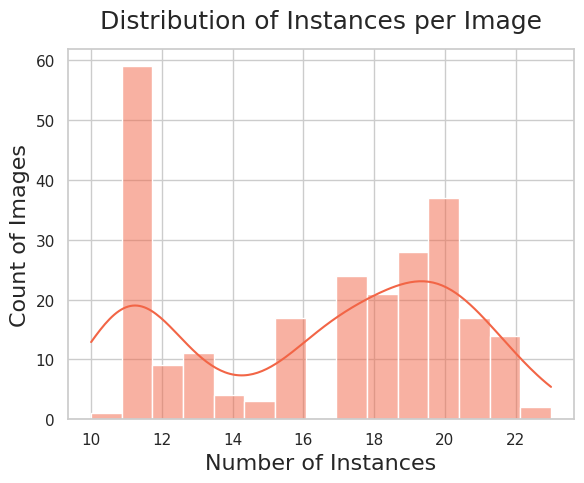

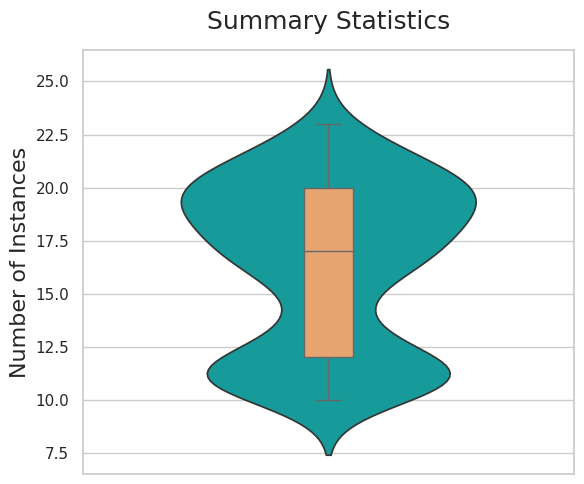

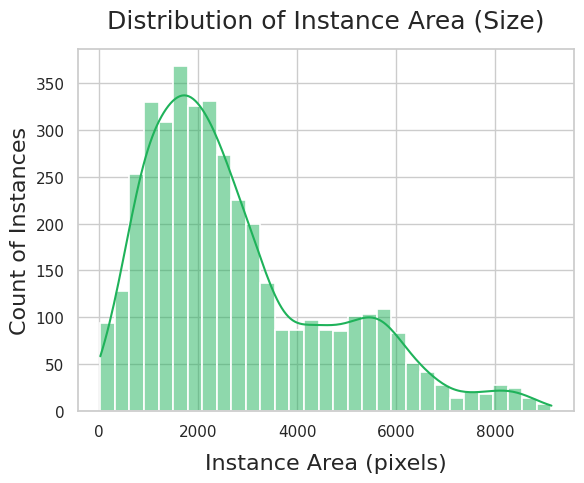

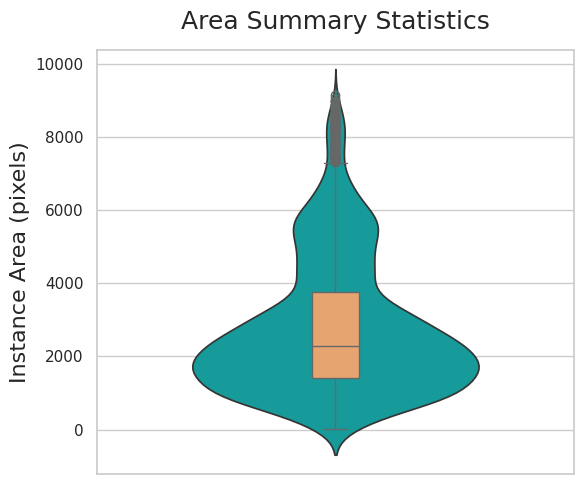

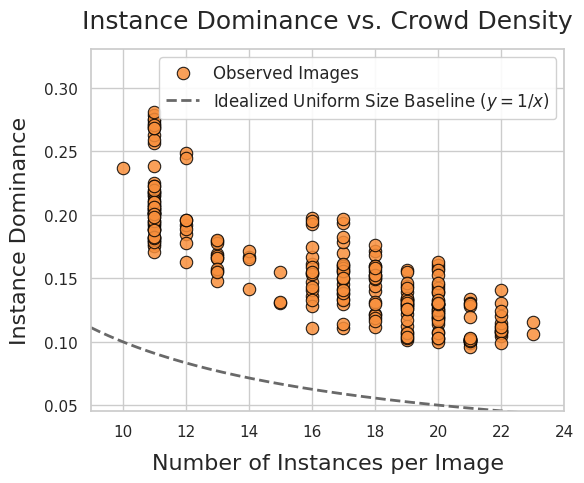

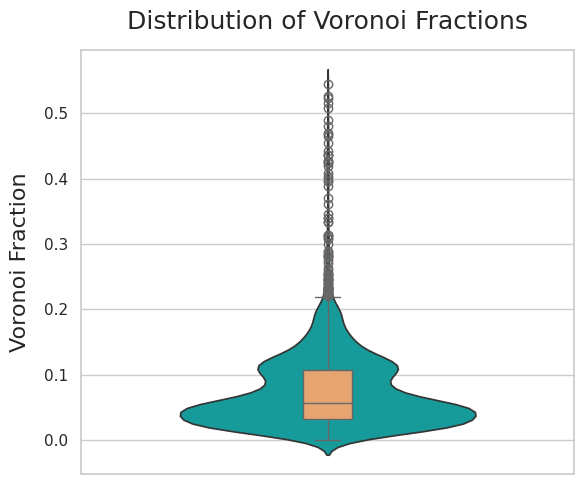

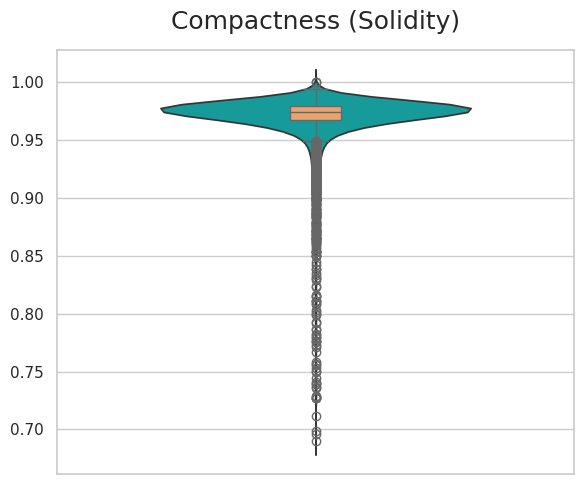

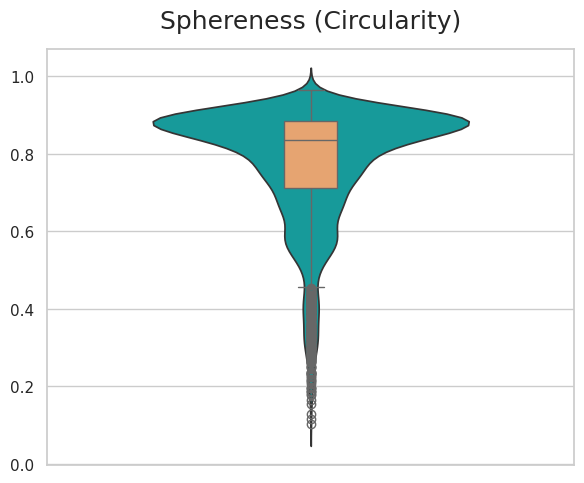

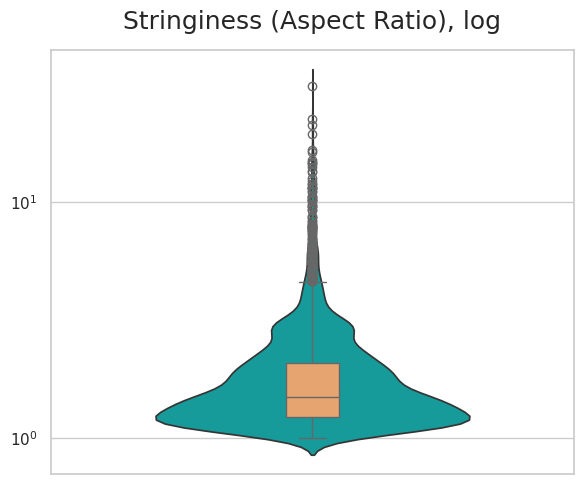

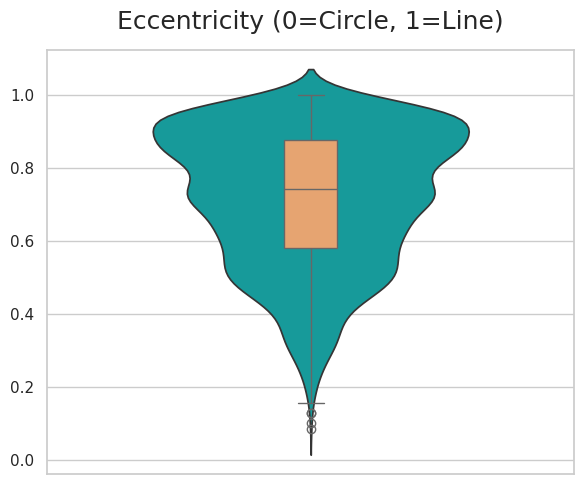

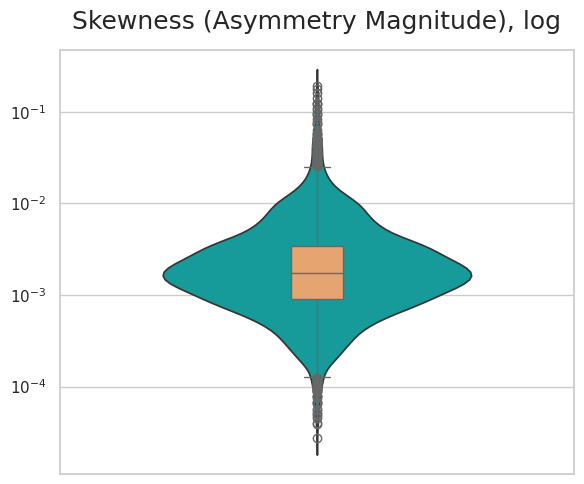

In [96]:
os.makedirs(f'../docs/thesis/figures/metrics/{task}', exist_ok=True)

# Set style
sns.set_theme(style="whitegrid", palette="muted")

# Unique image level data
image_df = df_metrics[['image_idx',
                       'num_instances_in_image']].drop_duplicates()

fig, axes = plt.subplots(figsize=(6, 5))

# Plot 1: Distribution of instances per image
sns.histplot(data=image_df, x='num_instances_in_image',
             kde=True, ax=axes, color='#f26546', bins=15)
axes.set_title('Distribution of Instances per Image', fontsize=18, pad=15)
axes.set_xlabel('Number of Instances', fontsize=16)
axes.set_ylabel('Count of Images', fontsize=16)

fig.savefig(f'../docs/thesis/figures/metrics/{task}/num_instances_hist.png', dpi=300)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(6, 5))

# Plot 2: Violin plot for summary statistics
sns.violinplot(data=image_df, y='num_instances_in_image', ax=axes, color='#01b0b0', inner=None, width=0.6)
sns.boxplot(data=image_df, y='num_instances_in_image', ax=axes, color='#f9a25e', width=0.1)
axes.set_title('Summary Statistics', fontsize=18, pad=15)
axes.set_ylabel('Number of Instances', fontsize=16)
axes.set_xticklabels([])

fig.savefig(
    f'../docs/thesis/figures/metrics/{task}/num_instances_violin.png', dpi=300)

plt.tight_layout()
plt.show()

# ==============================================================================
# 1. INSTANCE AREA (SIZE DISTRIBUTION)
# ==============================================================================
fig, axes = plt.subplots(figsize=(6, 5))

sns.histplot(data=df_metrics, x='instance_area', kde=True,
             ax=axes, color='#1fb25a', edgecolor='w', linewidth=1.2)
axes.set_title('Distribution of Instance Area (Size)', fontsize=18, pad=15)
axes.set_xlabel('Instance Area (pixels)', fontsize=16, labelpad=10)
axes.set_ylabel('Count of Instances', fontsize=16)

fig.savefig(
    f'../docs/thesis/figures/metrics/{task}/instance_area_hist.png', dpi=300)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(6, 5))

sns.violinplot(data=df_metrics, y='instance_area', ax=axes, color='#01b0b0', inner=None, width=0.6)
sns.boxplot(data=df_metrics, y='instance_area', ax=axes, color='#f9a25e', width=0.1)
axes.set_title('Area Summary Statistics', fontsize=18, pad=15)
axes.set_ylabel('Instance Area (pixels)', fontsize=16)
axes.set_xticklabels([])

fig.savefig(
    f'../docs/thesis/figures/metrics/{task}/instance_area_violin.png', dpi=300)

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. INSTANCE DOMINANCE VS. NUMBER OF INSTANCES
# ==============================================================================
fig, axes = plt.subplots(figsize=(6, 5))

# Extract unique image-level statistics for accurate pairing
image_level_df = df_metrics[['image_idx', 'num_instances_in_image', 'instance_dominance']].drop_duplicates()

# Calculate dynamic bounds with padding
min_observed_x = image_level_df['num_instances_in_image'].min()
max_observed_x = image_level_df['num_instances_in_image'].max()

padding_x = 1.0  # 1 instance padding on either side
x_start = max(1, min_observed_x - padding_x)
x_end = max_observed_x + padding_x

sns.scatterplot(
    data=image_level_df, 
    x='num_instances_in_image', 
    y='instance_dominance', 
    ax=axes,
    color='#f88f3c', 
    s=80, 
    alpha=0.85, 
    edgecolor='black', 
    linewidth=0.8,
    label='Observed Images'
)

# Generate baseline curve only within the cropped range
x_curve = np.linspace(x_start, x_end, 300)
y_curve = 1 / x_curve
axes.plot(x_curve, y_curve, color='dimgray', linestyle='--',
          linewidth=2, label=r'Idealized Uniform Size Baseline ($y = 1/x$)')

axes.set_title('Instance Dominance vs. Crowd Density', fontsize=18, pad=15)
axes.set_xlabel('Number of Instances per Image', fontsize=16, labelpad=10)
axes.set_ylabel('Instance Dominance', fontsize=16, labelpad=10)

# Set dynamic limits
axes.set_xlim(x_start, x_end)

# Adjust y-limits dynamically based on observed dominance to maximize focus, but keep a logical ceiling/floor if needed
min_observed_y = image_level_df['instance_dominance'].min()
max_observed_y = image_level_df['instance_dominance'].max()
padding_y = 0.05
axes.set_ylim(max(0, min_observed_y - padding_y),
              min(1.05, max_observed_y + padding_y))

axes.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=12)

fig.savefig(
    f'../docs/thesis/figures/metrics/{task}/instance_dominance.png', dpi=300)
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. VORONOI FRACTION
# ==============================================================================
fig, axes = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df_metrics, y='voronoi_fraction',
               ax=axes, color='#01b0b0', inner=None, width=0.6)
sns.boxplot(data=df_metrics, y='voronoi_fraction',
            ax=axes, color='#f9a25e', width=0.1)

axes.set_title('Distribution of Voronoi Fractions', fontsize=18, pad=15)
axes.set_ylabel('Voronoi Fraction', fontsize=16, labelpad=10)
axes.set_xticklabels([])

fig.savefig(
    f'../docs/thesis/figures/metrics/{task}/voronoi_fraction.png', dpi=300)

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. MORPHOLOGICAL ATTRIBUTES PROFILE MATRIX
# ==============================================================================
fig, axes = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df_metrics, y='compactness',
               ax=axes, color='#01b0b0', inner=None, width=0.6)
sns.boxplot(data=df_metrics, y='compactness',
            ax=axes, color='#f9a25e', width=0.1)

axes.set_title('Compactness (Solidity)', fontsize=18, pad=15)
axes.set_xticklabels([])
axes.set_ylabel('')

fig.savefig(f'../docs/thesis/figures/metrics/{task}/compactness.png', dpi=300)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df_metrics, y='sphereness',
               ax=axes, color='#01b0b0', inner=None, width=0.6)
sns.boxplot(data=df_metrics, y='sphereness',
            ax=axes, color='#f9a25e', width=0.1)

axes.set_title('Sphereness (Circularity)', fontsize=18, pad=15)
axes.set_xticklabels([])
axes.set_ylabel('')

fig.savefig(f'../docs/thesis/figures/metrics/{task}/sphereness.png', dpi=300)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df_metrics, y='stringiness',
               ax=axes, color='#01b0b0', inner=None, width=0.6, log_scale=True)
sns.boxplot(data=df_metrics, y='stringiness',
            ax=axes, color='#f9a25e', width=0.1, log_scale=True)

axes.set_title('Stringiness (Aspect Ratio), log', fontsize=18, pad=15)
axes.set_xticklabels([])
axes.set_ylabel('')

fig.savefig(f'../docs/thesis/figures/metrics/{task}/stringiness.png', dpi=300)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df_metrics, y='eccentricity',
               ax=axes, color='#01b0b0', inner=None, width=0.6)
sns.boxplot(data=df_metrics, y='eccentricity',
            ax=axes, color='#f9a25e', width=0.1)

axes.set_title('Eccentricity (0=Circle, 1=Line)', fontsize=18, pad=15)
axes.set_xticklabels([])
axes.set_ylabel('')

fig.savefig(f'../docs/thesis/figures/metrics/{task}/eccentricity.png', dpi=300)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(figsize=(6, 5))
sns.violinplot(data=df_metrics, y='skewness',
               ax=axes, color='#01b0b0', inner=None, width=0.6, log_scale=True)
sns.boxplot(data=df_metrics, y='skewness',
            ax=axes, color='#f9a25e', width=0.1, log_scale=True)

axes.set_title('Skewness (Asymmetry Magnitude), log', fontsize=18, pad=15)
axes.set_xticklabels([])
axes.set_ylabel('')

fig.savefig(f'../docs/thesis/figures/metrics/{task}/skewness.png', dpi=300)

plt.tight_layout()
plt.show()